In [ ]:
#Trocar o caminho do arquivo para o caminho do seu computador
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt


print(os.getcwd())

c:\Users\jessi\Pos FISP\Desafios Pos\Projeto_1


In [57]:
import pandas as pd
import matplotlib.pyplot as plt

pasta = r"C:\Users\jessi\Pos FISP\Desafios Pos\Projeto_1\dados.db"

orders = pd.read_csv(
    f"{pasta}/olist_orders_dataset.csv",
    usecols=["order_id", "order_purchase_timestamp", "customer_id"],
    parse_dates=["order_purchase_timestamp"]
)

orders["ano"] = orders["order_purchase_timestamp"].dt.year


order_items = pd.read_csv(
    f"{pasta}/olist_order_items_dataset.csv",
    usecols=["order_id", "product_id", "price"]
)


products = pd.read_csv(
    f"{pasta}/olist_products_dataset.csv",
    usecols=["product_id", "product_category_name", "product_name_lenght"]
)

payments = pd.read_csv(
    f"{pasta}/olist_order_payments_dataset.csv",
    usecols=["order_id", "payment_type", "payment_installments", "payment_value"]
)

customers = pd.read_csv(
    f"{pasta}/olist_customers_dataset.csv",
    usecols=["customer_id", "customer_city", "customer_state"]
)


products_moveis = products.loc[
    products["product_category_name"] == "moveis_decoracao",
    ["product_id", "product_name_lenght"]
]


df = (
    order_items
    .merge(products_moveis, on="product_id", how="inner")
    .merge(orders, on="order_id", how="inner")
    .merge(customers, on="customer_id", how="inner")
    .merge(payments, on="order_id", how="inner")
)


resultado = (
    df.groupby(["ano", "customer_city", "customer_state", "product_name_lenght"])
    .agg(
        pedidos=("order_id", "nunique"),
        itens=("order_id", "size"),
        faturamento=("price", "sum")
    )
    .reset_index()
    .sort_values(["ano", "itens"], ascending=[True, False])
)

print(resultado)

       ano   customer_city customer_state  product_name_lenght  pedidos  \
40    2016  rio de janeiro             RJ                 50.0        1   
6     2016  belo horizonte             MG                 64.0        1   
23    2016        curitiba             PR                 56.0        1   
36    2016  novo progresso             PA                 59.0        1   
3     2016         barueri             SP                 63.0        1   
...    ...             ...            ...                  ...      ...   
4284  2018     votuporanga             SP                 53.0        1   
4285  2018     votuporanga             SP                 60.0        1   
4287  2018  wenceslau braz             PR                 58.0        1   
4288  2018           xaxim             SC                 45.0        1   
4289  2018           xaxim             SC                 57.0        1   

      itens  faturamento  
40        7        475.3  
6         3         86.7  
23        3       

C:\Users\jessi\AppData\Local\Temp\ipykernel_15832\2267869000.py:37: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


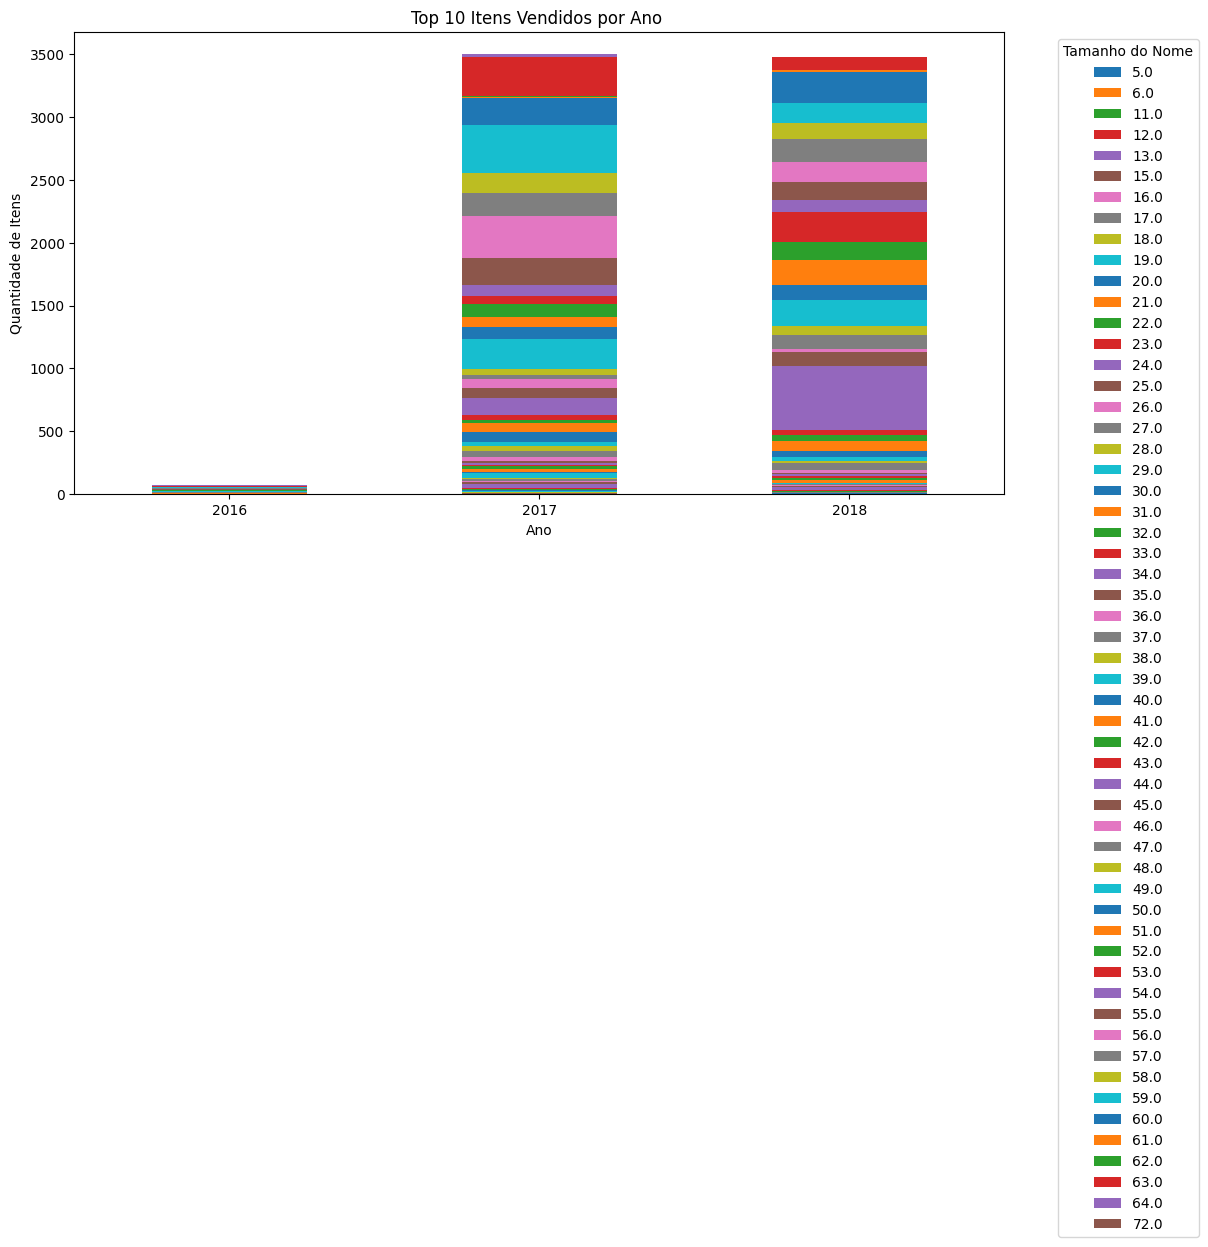

In [44]:

# Grafico pegando somente o top 10 de cada ano (QUANTIDADE DE ITENS)

top10 = (
    resultado
    .sort_values(["ano", "itens"], ascending=[True, False])
    .groupby(["ano", "customer_state", "customer_city"])
    .head(10)
)

pivot = top10.pivot_table(
    index="ano",
    columns="product_name_lenght",
    values="itens",
    aggfunc="sum"
).fillna(0)

# GRÁFICO EMPILHADO

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Top 10 Itens Vendidos por Ano ")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Itens")

plt.xticks(rotation=0)

plt.legend(
    title="Tamanho do Nome",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

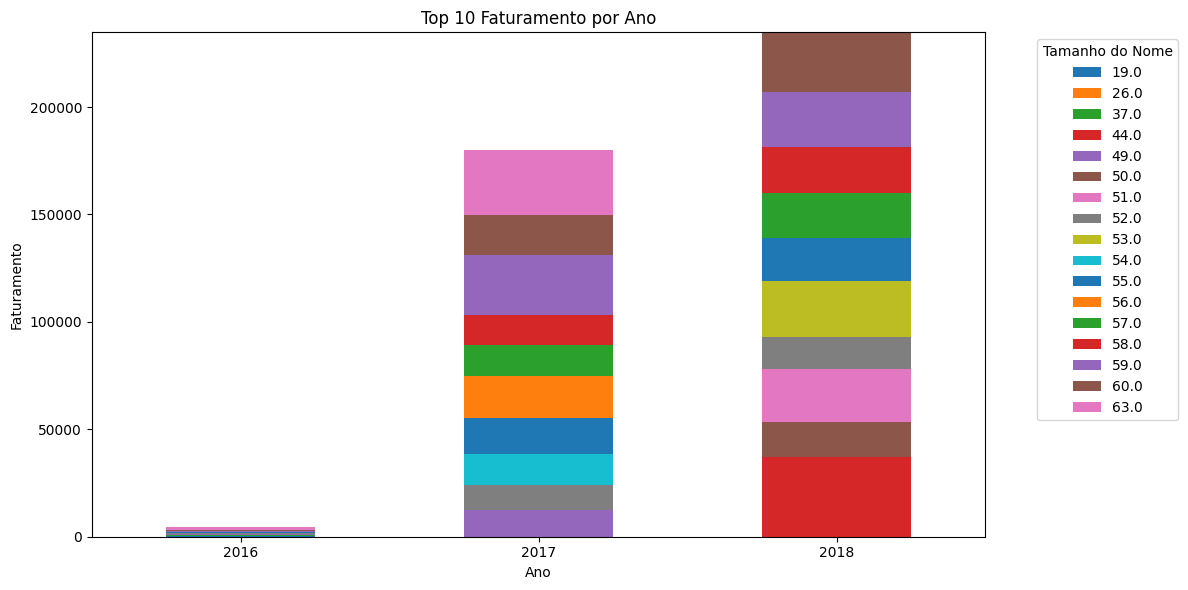

In [34]:
# Grafico pegando somente o top 10 de cada ano (por faturamento)

top10 = (
    resultado
    .reset_index()
    .sort_values(["ano", "faturamento"], ascending=[True, False])
    .groupby("ano")
    .head(10)
)

pivot = top10.pivot_table(
    index="ano",
    columns="product_name_lenght",
    values="faturamento",
    aggfunc="sum"
).fillna(0)

# GRÁFICO EMPILHADO

pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Top 10 Faturamento por Ano")
plt.xlabel("Ano")
plt.ylabel("Faturamento")

plt.xticks(rotation=0)

plt.legend(
    title="Tamanho do Nome",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

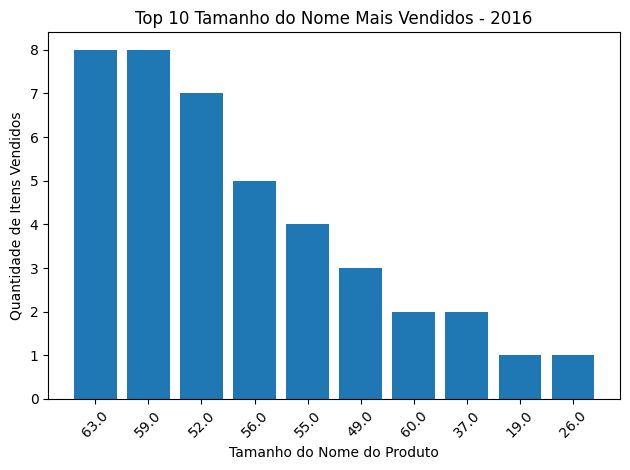

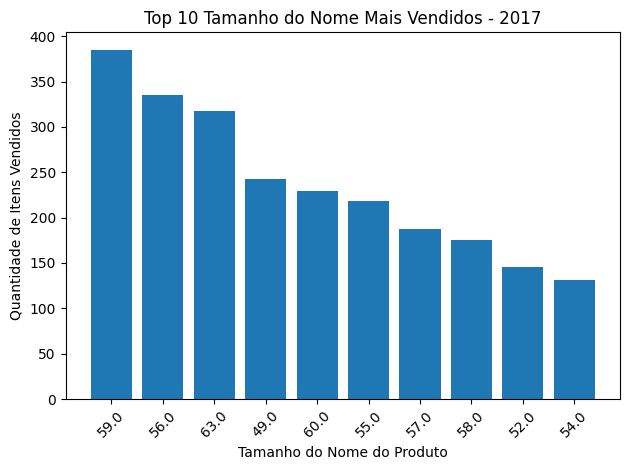

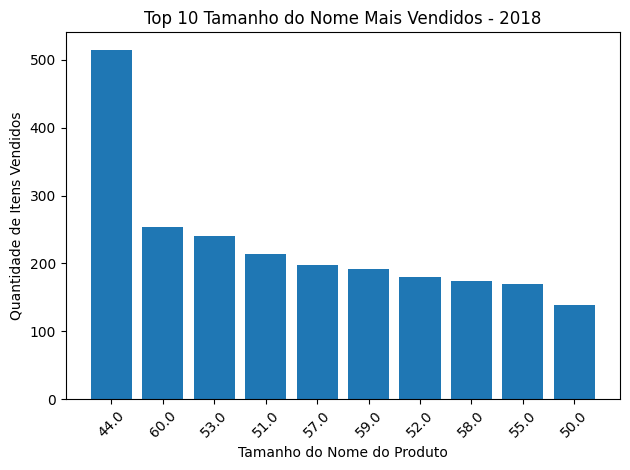

In [ ]:

# Grafico de como foi de cada ano (QUANTIDADE DE ITENS)
top10 = top10.sort_values(["ano", "itens"], ascending=[True, False])

for ano, grupo in top10.groupby("ano"):
    
    plt.figure()
    
    plt.bar(
        grupo["product_name_lenght"].astype(str), 
        grupo["itens"]
    )
    
    plt.title(f"Top 10 Tamanho do Nome Mais Vendidos - {ano}")
    plt.xlabel("Tamanho do Nome do Produto")
    plt.ylabel("Quantidade de Itens Vendidos")
    
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

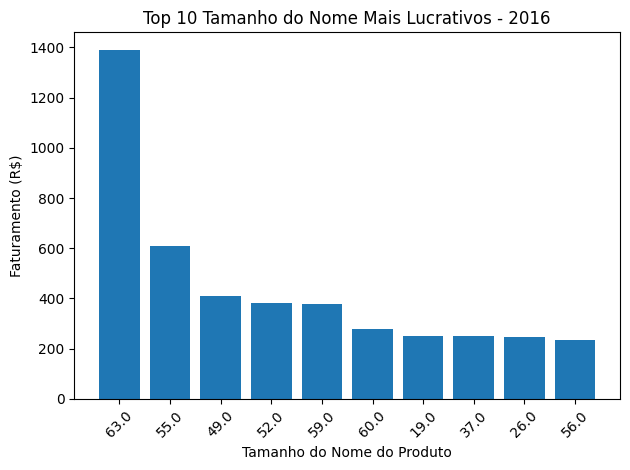

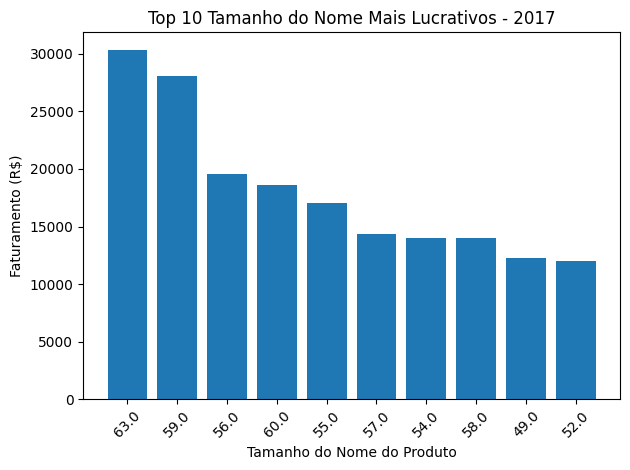

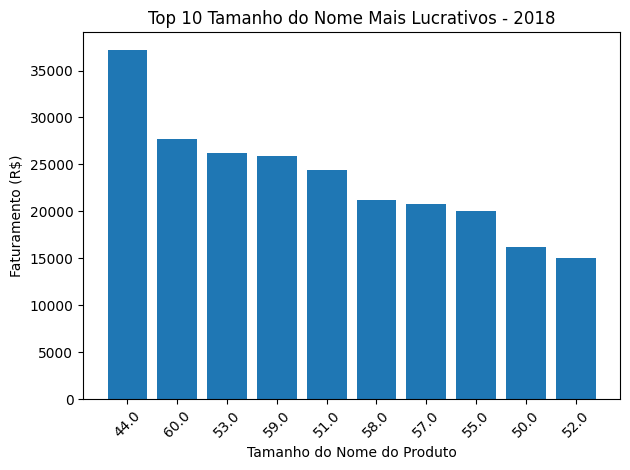

In [30]:
# Ordenar por ano e faturamento
top10 = top10.sort_values(["ano", "faturamento"], ascending=[True, False])

# Criar gráfico por ano
for ano, grupo in top10.groupby("ano"):
    
    plt.figure()
    
    plt.bar(
        grupo["product_name_lenght"].astype(str), 
        grupo["faturamento"]
    )
    
    plt.title(f"Top 10 Tamanho do Nome Mais Lucrativos - {ano}")
    plt.xlabel("Tamanho do Nome do Produto")
    plt.ylabel("Faturamento (R$)")
    
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

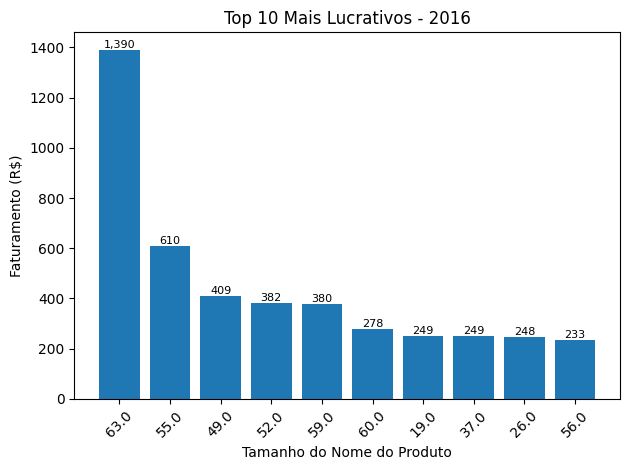

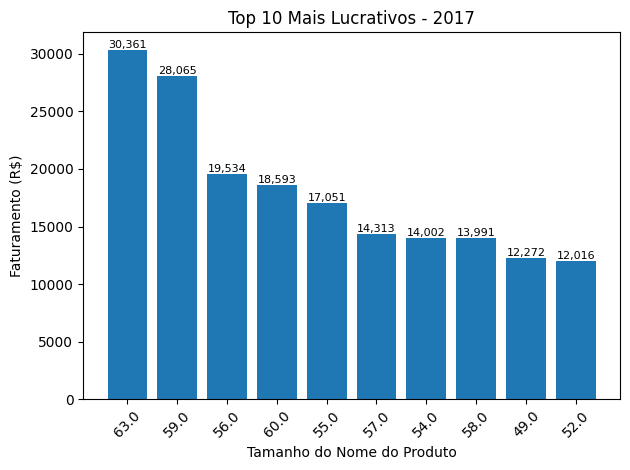

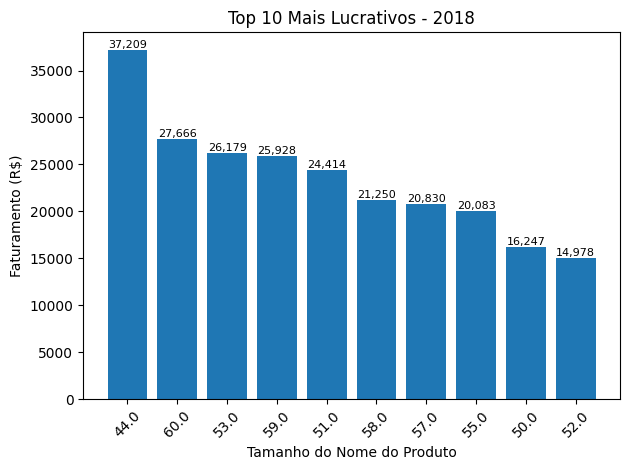

In [ ]:
# Ordenar por ano e faturamento
top10 = top10.sort_values(["ano", "faturamento"], ascending=[True, False])

for ano, grupo in top10.groupby("ano"):
    
    plt.figure()
    
    bars = plt.bar(
        grupo["product_name_lenght"].astype(str), 
        grupo["faturamento"]
    )
    
    total_ano = grupo["faturamento"].sum()
    
    plt.title(f"Top 10 Mais Lucrativos - {ano}")
    plt.xlabel("Tamanho do Nome do Produto")
    plt.ylabel("Faturamento (R$)")
    
    plt.xticks(rotation=45)
    
    # mostrar valor em cima das barras
    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y,
            f"{y:,.0f}",
            ha='center',
            va='bottom',
            fontsize=8
        )
    
    plt.tight_layout()
    plt.show()

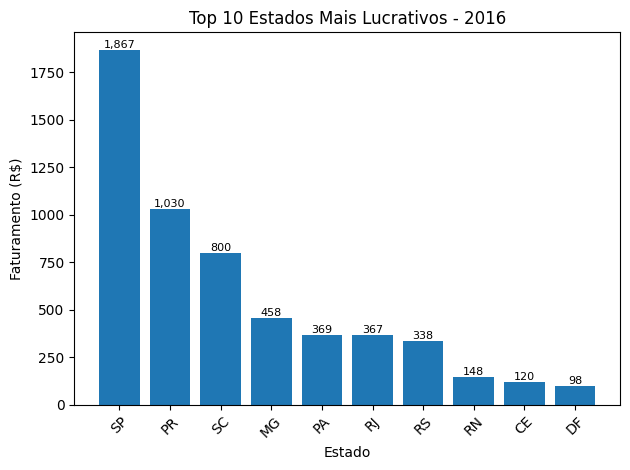

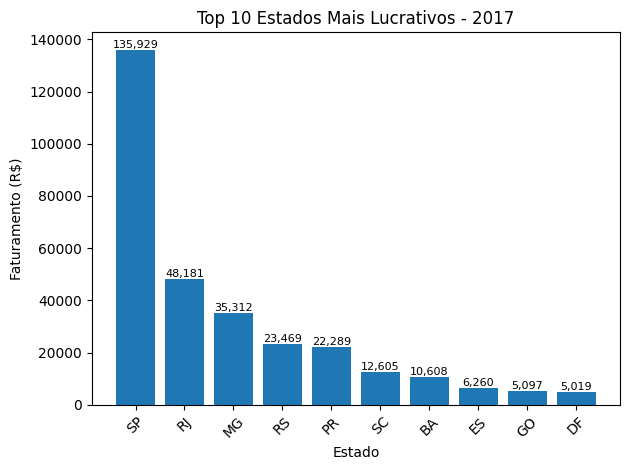

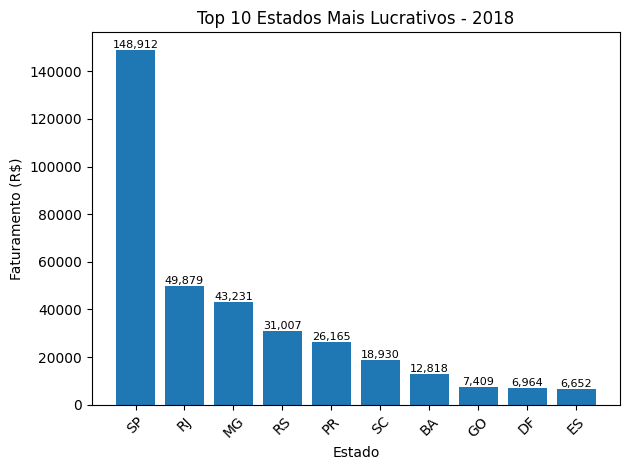

In [48]:
# 1. Consolidar corretamente antes do gráfico
top10 = (
    resultado
    .groupby(["ano", "customer_state"])
    .agg(faturamento=("faturamento", "sum"))
    .reset_index()
)

# 2. Ordenar e pegar TOP 10 por ano
top10 = top10.sort_values(["ano", "faturamento"], ascending=[True, False])
top10 = top10.groupby("ano").head(10)


# 3. Plot
for ano, grupo in top10.groupby("ano"):
    
    plt.figure()
    
    bars = plt.bar(
        grupo["customer_state"].astype(str),
        grupo["faturamento"]
    )
    
    total_ano = grupo["faturamento"].sum()
    
    plt.title(f"Top 10 Estados Mais Lucrativos - {ano}")
    plt.xlabel("Estado")
    plt.ylabel("Faturamento (R$)")
    
    plt.xticks(rotation=45)
    
    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y,
            f"{y:,.0f}",
            ha='center',
            va='bottom',
            fontsize=8
        )
    
    plt.tight_layout()
    plt.show()

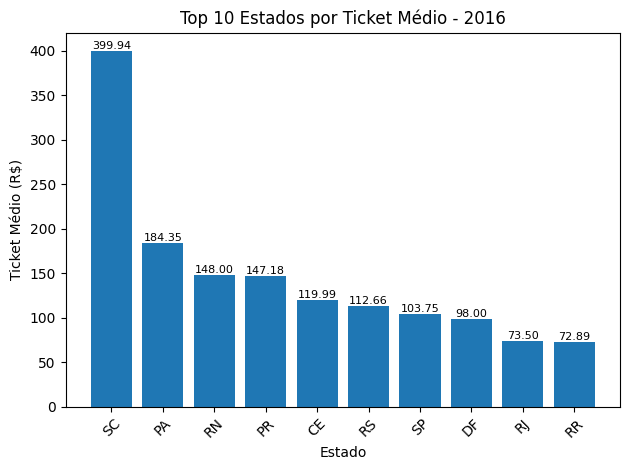

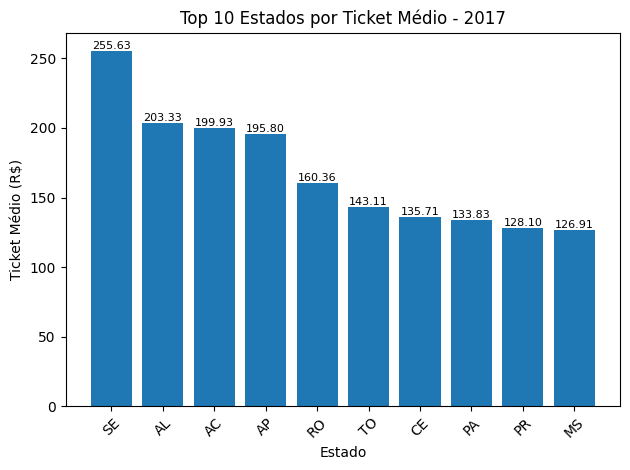

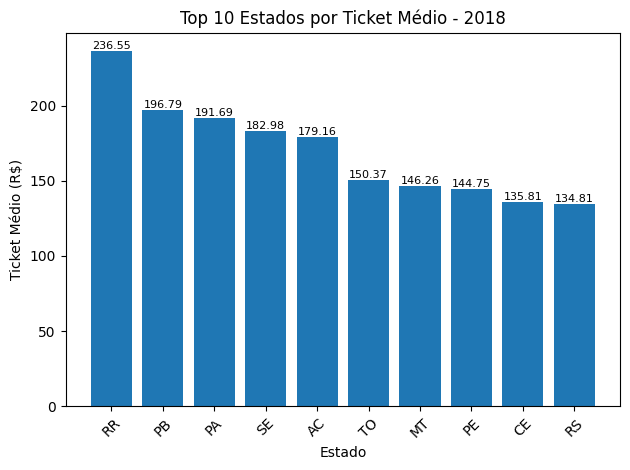

In [ ]:
#  CÁLCULO DO TICKET MÉDIO

ticket_estado = (
    df.groupby(["ano", "customer_state"])
    .agg(
        faturamento=("price", "sum"),
        pedidos=("order_id", "nunique")
    )
    .reset_index()
)

ticket_estado["ticket_medio"] = (
    ticket_estado["faturamento"] / ticket_estado["pedidos"]
)

top10 = (
    ticket_estado
    .sort_values(["ano", "ticket_medio"], ascending=[True, False])
    .groupby("ano")
    .head(10)
)

for ano, grupo in top10.groupby("ano"):
    
    plt.figure()
    
    bars = plt.bar(
        grupo["customer_state"].astype(str),
        grupo["ticket_medio"]
    )
    
    plt.title(f"Top 10 Estados por Ticket Médio - {ano}")
    plt.xlabel("Estado")
    plt.ylabel("Ticket Médio (R$)")
    
    plt.xticks(rotation=45)
    
    # valores nas barras
    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y,
            f"{y:,.2f}",
            ha='center',
            va='bottom',
            fontsize=8
        )
    
    plt.tight_layout()
    plt.show()

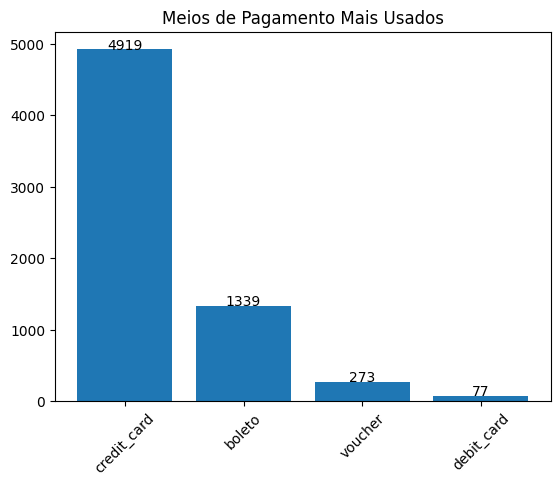

In [ ]:
#MEIOS DE PAGAMENTO MAIS USADOS
payment_counts = (
    df.groupby("payment_type")
    .agg(pedidos=("order_id", "nunique"))
    .reset_index()
    .sort_values("pedidos", ascending=False)
)

plt.figure()

bars = plt.bar(
    payment_counts["payment_type"],
    payment_counts["pedidos"]
)

plt.title("Meios de Pagamento Mais Usados")
plt.xticks(rotation=45)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             int(bar.get_height()),
             ha='center')

plt.show()

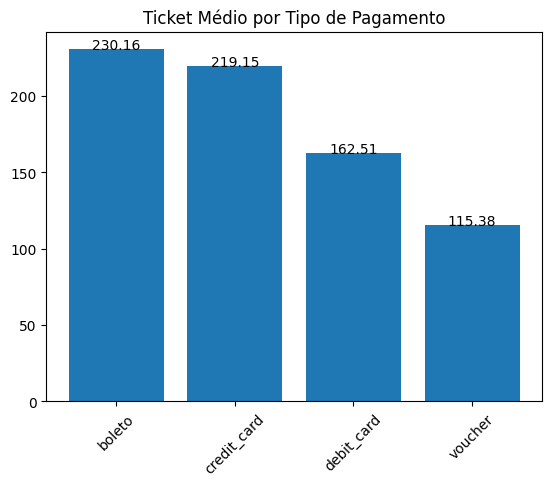

In [59]:
ticket = (
    df.groupby("payment_type")
    .agg(
        faturamento=("payment_value", "sum"),
        pedidos=("order_id", "nunique")
    )
    .reset_index()
)

ticket["ticket_medio"] = ticket["faturamento"] / ticket["pedidos"]

plt.figure()

bars = plt.bar(ticket["payment_type"], ticket["ticket_medio"])

plt.title("Ticket Médio por Tipo de Pagamento")
plt.xticks(rotation=45)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height(),
             f"{bar.get_height():.2f}",
             ha='center')

plt.show()

    ano payment_type
0  2018  credit_card
1  2017  credit_card
2  2017       boleto
3  2018  credit_card
4  2018  credit_card


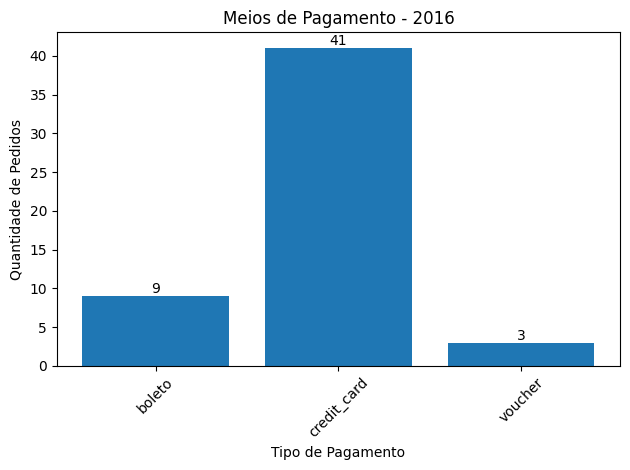

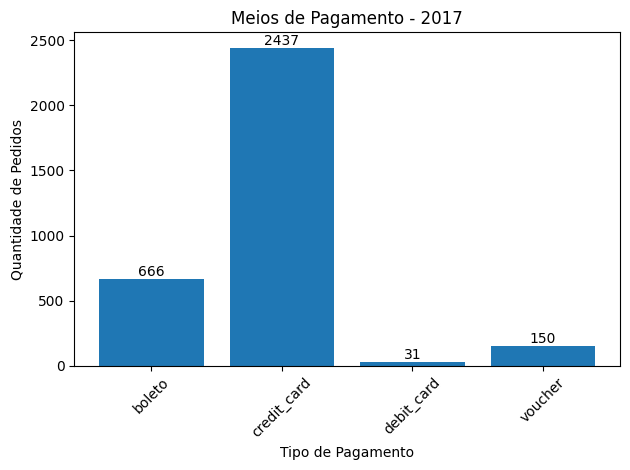

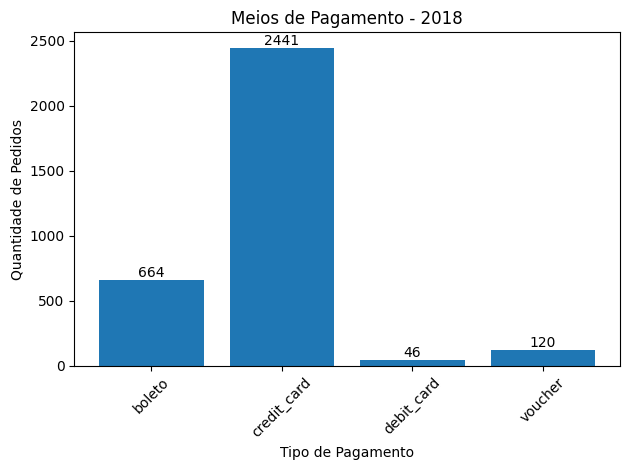

In [ ]:
df = df.merge(
    payments[["order_id", "payment_type", "payment_value", "payment_installments"]],
    on="order_id",
    how="inner"
)

print(df[["ano", "payment_type"]].head())

pagamentos_ano = (
    df.groupby(["ano", "payment_type"])
    .agg(
        pedidos=("order_id", "nunique"),
        valor=("payment_value", "sum")
    )
    .reset_index()
)

for ano, grupo in pagamentos_ano.groupby("ano"):
    
    plt.figure()
    
    bars = plt.bar(
        grupo["payment_type"],
        grupo["pedidos"]
    )
    
    plt.title(f"Meios de Pagamento - {ano}")
    plt.xlabel("Tipo de Pagamento")
    plt.ylabel("Quantidade de Pedidos")
    
    plt.xticks(rotation=45)
    
    # valores nas barras
    for bar in bars:
        y = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            y,
            int(y),
            ha='center',
            va='bottom'
        )
    
    plt.tight_layout()
    plt.show()